In [6]:
!pip install matplotlib

In [10]:
# =========================
# CONFIG
# =========================

img_dir = "synth_large_0906/sequences/seq_000001/instance_masks/frame_000036.png"

Mask shape: (720, 1280)
Mask dtype: uint16
Instance IDs present: [0 1 2 3 4 5]


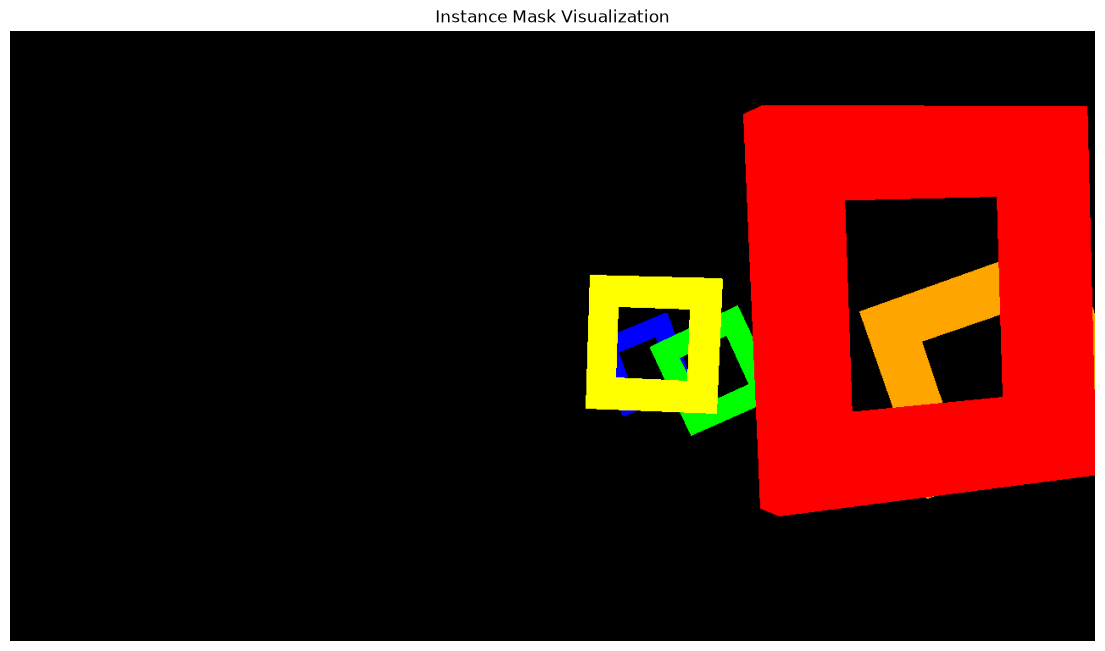

In [11]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


# =========================
# LOAD INSTANCE MASK
# =========================

MASK_PATH = Path(img_dir)

mask = cv2.imread(str(MASK_PATH), cv2.IMREAD_UNCHANGED)

if mask is None:
    raise FileNotFoundError(f"Could not load mask: {MASK_PATH}")

if mask.ndim != 2:
    raise ValueError(
        f"Expected a single-channel instance mask, got shape {mask.shape}"
    )

print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)
print("Instance IDs present:", np.unique(mask))


# =========================
# COLOR MAP
# =========================

# RGB colors
INSTANCE_COLORS = {
    0: (0, 0, 0),         # background = black
    1: (255, 0, 0),       # red
    2: (255, 165, 0),     # orange
    3: (255, 255, 0),     # yellow
    4: (0, 255, 0),       # green
    5: (0, 0, 255),       # blue
    6: (128, 0, 128),     # purple
    7: (255, 0, 255),     # magenta
    8: (0, 255, 255),     # cyan
    9: (255, 192, 203),   # pink
    10: (165, 42, 42),    # brown
}


# =========================
# CREATE COLOR IMAGE
# =========================

H, W = mask.shape

colored_mask = np.zeros((H, W, 3), dtype=np.uint8)

for instance_id in np.unique(mask):

    instance_id = int(instance_id)

    if instance_id in INSTANCE_COLORS:
        color = INSTANCE_COLORS[instance_id]
    else:
        # deterministic fallback color for IDs > 10
        rng = np.random.default_rng(instance_id)
        color = tuple(
            rng.integers(40, 256, size=3).tolist()
        )

    colored_mask[mask == instance_id] = color


# =========================
# DISPLAY
# =========================

plt.figure(figsize=(14, 8))

plt.imshow(colored_mask)
plt.title("Instance Mask Visualization")
plt.axis("off")

plt.show()

